# 4. Регрессия

**Текст задания.** В каждом из заданий, если не сказано иного, необходимо использовать хотя бы 3 метода из следующих: случайный лес, метод наименьших квадратов, метод ближайших соседей и градиентный бустинг.

**Выполнение.** В этом разделе решается задача прогнозирования непрерывной целевой переменной `monthly_spending`. Обозначим ее как $Y_i$, а вектор признаков клиента как $X_i$. Цель регрессионной модели - построить функцию $\hat f(X_i)$, которая приближает условное математическое ожидание:

$$\hat Y_i = \hat f(X_i) \approx E(Y_i \mid X_i).$$

В соответствии с условием задания переменная воздействия `premium_subscription` не включается в признаки. Это важно: если бы мы добавили воздействие в регрессионную модель прогноза, модель частично использовала бы информацию о treatment, что нарушило бы постановку блока регрессии и могло бы повлиять на последующий анализ эффектов воздействия.

**Выполнение.** Сначала подготавливается общий контекст для всего блока: импортируются библиотеки, загружаются данные, выбираются признаки и целевая переменная, задаются метрики качества. Дальше все модели обучаются на одном и том же train/test split, чтобы сравнение было корректным.

Перед выполнением задания подключаем инструменты, которые использовались в семинарах: `train_test_split` для разделения выборки, `cross_val_score` и `GridSearchCV` для кросс-валидации и тюнинга гиперпараметров, а также регрессионные модели из `sklearn`. Для KNN дополнительно используется `Pipeline` со `StandardScaler`, потому что, как обсуждалось на семинаре про метод ближайших соседей, расстояния зависят от масштаба признаков.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn import metrics
from sklearn.metrics import make_scorer

Загружаем сгенерированные ранее данные из `df.csv` и смотрим на первые строки. Это техническая проверка перед моделированием: в таблице должны быть целевая переменная `monthly_spending`, переменная воздействия `premium_subscription` и наблюдаемые признаки, которые могут использоваться для прогноза.

In [2]:
df = pd.read_csv("df.csv")
df.head()

,monthly_spending,premium_subscription,income,age,urban_area,family_size,free_trial_banner
0,11721.117830,1,38452.719412,24.0,1,2,0
1,10911.269377,1,108953.092363,27.0,1,2,1
2,8642.447791,0,76228.390348,53.0,1,1,0
3,1.000000,0,31158.820400,52.0,1,1,0
4,7228.550018,0,49548.133698,48.0,0,3,0


В данных есть непрерывная целевая переменная `monthly_spending`, бинарная переменная воздействия `premium_subscription` и набор наблюдаемых характеристик клиента. В регрессионном блоке мы прогнозируем именно траты, а не факт подписки. Переменная воздействия дальше исключается из матрицы признаков, как требует задание.

## Задание 4.1

**Текст задания.** Отберите признаки, которые могут быть полезны при прогнозировании целевой (зависимой) переменной. Не включайте в число этих признаков переменную воздействия.

**Выполнение.** Ниже задаются целевая переменная и матрица признаков для регрессионных моделей. Формально мы используем:

$$Y_i = \text{monthly\_spending}_i,$$

$$X_i = (\text{income}_i, \text{age}_i, \text{urban\_area}_i, \text{family\_size}_i, \text{free\_trial\_banner}_i).$$

Переменная воздействия $D_i = \text{premium\_subscription}_i$ не входит в $X_i$.

В качестве признаков используются доход, возраст, тип территории, размер семьи и инструмент `free_trial_banner`. Такой набор содержательно связан с месячными тратами: доход отражает платежеспособность, возраст - жизненный цикл клиента, городская территория - доступность сервиса, размер семьи - потенциальный объем потребления. `free_trial_banner` не является переменной воздействия; это инструментальная переменная из процесса генерации, поэтому ее включение не нарушает прямой запрет на `premium_subscription`.

In [3]:
target = np.ravel(df.loc[:, ['monthly_spending']])
features = df.loc[:, ['income', 'age', 'urban_area', 'family_size', 'free_trial_banner']]

pd.DataFrame({
    'переменная': ['monthly_spending'] + list(features.columns),
    'роль': ['целевая переменная'] + ['признак'] * features.shape[1]
})

,переменная,роль
0,monthly_spending,целевая переменная
1,income,признак
2,age,признак
3,urban_area,признак
4,family_size,признак
5,free_trial_banner,признак


Полученная матрица признаков содержит только наблюдаемые переменные и не содержит `premium_subscription`. Это согласуется с формулировкой задания и с логикой последующих causal-разделов: модели машинного обучения должны прогнозировать $Y$ по наблюдаемым covariates, не используя сам факт воздействия как готовую подсказку.

Разделяем данные на обучающую и тестовую выборки в пропорции 75/25. Это соответствует условию блока генерации, где тестовая часть должна составлять от 20% до 30% наблюдений. Обучающая выборка используется для подбора и оценки моделей внутри обучения, а тестовая - для финального вневыборочного контроля.

In [4]:
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size = 0.25, random_state = 123)

features_train_raw = features_train.copy()
features_test_raw = features_test.copy()

pd.Series({
    'n_train': len(target_train),
    'n_test': len(target_test),
    'test_share': len(target_test) / len(target)
})

n_train       22500.00
n_test         7500.00
test_share        0.25
dtype: float64

Обучающая выборка используется для оценки моделей и подбора гиперпараметров, а тестовая выборка остается внешней проверкой. Такая схема соответствует семинарской логике: сначала модель обучается и настраивается на train, затем качество проверяется на данных, которые не участвовали в обучении.

## Задание 4.2

**Текст задания.** Для каждого метода оцените `RMSE` и `MAPE`, используя произвольные значения гиперпараметров на обучающей выборке, тестовой выборке и с помощью кросс-валидации. С помощью кросс-валидации на обучающей выборке подберите оптимальные значения гиперпараметров. В одной таблице укажите исходные и подобранные значения гиперпараметров, а также `RMSE` и `MAPE`, рассчитанные на тестовой выборке и с помощью кросс-валидации до и после тюнинга. Обсудите наличие или отсутствие признаков переобучения модели и проинтерпретируйте полученные результаты.

**Выполнение.** Ниже задаются метрики качества, четыре регрессионных метода из списка задания, проводится оценка до тюнинга, затем подбор гиперпараметров через `GridSearchCV` и итоговое сравнение. Используются четыре метода: МНК, KNN, случайный лес и градиентный бустинг, то есть больше минимально требуемых трех.

Сначала задаем функции для двух метрик качества.

`RMSE` измеряет типичный масштаб ошибки в тех же единицах, что и целевая переменная:

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(Y_i - \hat Y_i)^2}.$$

Эта метрика особенно удобна для основной интерпретации, потому что ошибка выражается в единицах `monthly_spending`.

`MAPE` измеряет среднюю относительную ошибку:

$$MAPE = \frac{1}{n}\sum_{i=1}^{n}\left|\frac{Y_i - \hat Y_i}{Y_i}\right|.$$

В наших данных есть очень малые значения `monthly_spending`, поэтому `MAPE` становится менее устойчивой: даже небольшая абсолютная ошибка около маленького $Y_i$ дает большой относительный вклад. Поэтому `MAPE` используется как дополнительная метрика, а основной критерий сравнения - `RMSE`.

In [5]:
cv_all_reg = 5

def rmse(y_true, y_pred):
    return np.sqrt(metrics.mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

mape_scorer = make_scorer(mape, greater_is_better = False)

Далее задаем четыре регрессионных метода из списка задания.

1. **МНК** оценивает линейную зависимость:

$$\hat Y_i = \hat\beta_0 + X_i'\hat\beta.$$

Это базовая модель: она хорошо интерпретируема, но может хуже работать при нелинейностях.

2. **KNN-регрессия** прогнозирует значение как среднее или взвешенное среднее по ближайшим соседям. Расстояние между объектами зависит от масштаба признаков, поэтому, как в семинаре про KNN, стандартизация делается внутри `Pipeline`:

$$\tilde X_{ij} = \frac{X_{ij} - \bar X_j}{\hat\sigma_j}.$$

3. **Случайный лес** усредняет прогнозы нескольких деревьев:

$$\hat f_{RF}(x) = \frac{1}{B}\sum_{b=1}^{B}\hat f_b(x).$$

4. **Градиентный бустинг** строит ансамбль последовательно, исправляя ошибки предыдущих моделей:

$$F_{m+1}(x) = F_m(x) + \gamma h_m(x),$$

где $h_m(x)$ - очередное дерево, а $\gamma$ соответствует `learning_rate`.

In [6]:
regression_initial_models = {
    'МНК': LinearRegression(),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor(n_neighbors = 25, weights = 'distance'))
    ]),
    'Случайный лес': RandomForestRegressor(max_depth = 10,
                                           max_features = 'sqrt',
                                           n_estimators = 100,
                                           random_state = 777,
                                           criterion = 'squared_error'),
    'Градиентный бустинг': GradientBoostingRegressor(loss = 'squared_error',
                                                     n_estimators = 120,
                                                     learning_rate = 0.07,
                                                     max_depth = 3,
                                                     random_state = 123)
}

regression_initial_params = {
    'МНК': 'нет настраиваемых гиперпараметров',
    'KNN': 'n_neighbors=25, weights=distance, StandardScaler',
    'Случайный лес': 'max_depth=10, max_features=sqrt, n_estimators=100',
    'Градиентный бустинг': 'max_depth=3, learning_rate=0.07, n_estimators=120'
}

pd.Series(regression_initial_params, name = 'исходные гиперпараметры')

МНК                                    нет настраиваемых гиперпараметров
KNN                     n_neighbors=25, weights=distance, StandardScaler
Случайный лес          max_depth=10, max_features=sqrt, n_estimators=100
Градиентный бустинг    max_depth=3, learning_rate=0.07, n_estimators=120
Name: исходные гиперпараметры, dtype: object

Для каждого метода фиксируются исходные гиперпараметры. Это нужно, чтобы выполнить требование задания: сравнить качество до и после тюнинга. Гиперпараметры отвечают за сложность модели и риск переобучения: например, глубина деревьев управляет гибкостью леса и бустинга, число соседей в KNN регулирует баланс смещения и дисперсии, а `learning_rate` в бустинге задает размер шага при последовательном улучшении модели.

Оцениваем качество моделей с исходными гиперпараметрами. Для каждой модели считаются `RMSE` и `MAPE` на обучающей выборке, тестовой выборке и по 5-fold кросс-валидации на обучающей выборке.

Кросс-валидационная оценка строится как среднее по фолдам:

$$CV = \frac{1}{K}\sum_{k=1}^{K}Q_k,$$

где $Q_k$ - значение метрики на validation-части $k$-го фолда. Это соответствует семинарской логике `cross_val_score`: модель несколько раз обучается на части train и проверяется на оставшейся части train.

In [7]:
initial_rows = []

for model_name, model in regression_initial_models.items():
    model.fit(features_train_raw, target_train)
    pred_train = model.predict(features_train_raw)
    pred_test = model.predict(features_test_raw)
    rmse_cv = -np.mean(cross_val_score(model, features_train_raw, target_train,
                                       cv = cv_all_reg,
                                       scoring = 'neg_root_mean_squared_error'))
    mape_cv = -np.mean(cross_val_score(model, features_train_raw, target_train,
                                       cv = cv_all_reg,
                                       scoring = mape_scorer))

    initial_rows.append({
        'модель': model_name,
        'RMSE train до тюнинга': rmse(target_train, pred_train),
        'MAPE train до тюнинга': mape(target_train, pred_train),
        'RMSE test до тюнинга': rmse(target_test, pred_test),
        'MAPE test до тюнинга': mape(target_test, pred_test),
        'RMSE-CV до тюнинга': rmse_cv,
        'MAPE-CV до тюнинга': mape_cv
    })

regression_initial_summary = pd.DataFrame(initial_rows).set_index('модель')
regression_initial_summary.round(3)

,RMSE train до тюнинга,MAPE train до тюнинга,RMSE test до тюнинга,MAPE test до тюнинга,RMSE-CV до тюнинга,MAPE-CV до тюнинга
модель,,,,,,
МНК,5005.002,99.786,4983.135,97.411,5005.652,99.750
KNN,0.000,0.000,5004.848,99.046,5034.773,97.389
Случайный лес,4372.273,89.032,4749.337,99.927,4769.502,99.504
Градиентный бустинг,4672.241,95.501,4708.211,96.569,4729.153,96.689


По исходным гиперпараметрам лучший результат по `RMSE test` дает градиентный бустинг (`4708.211`), немного хуже работает случайный лес (`4749.337`), затем идут МНК и KNN. Это согласуется с устройством данных: зависимость `monthly_spending` от признаков нелинейная, поэтому ансамбли деревьев лучше аппроксимируют функцию $E(Y\mid X)$, чем линейная модель.

Особенно важен результат KNN: при `weights="distance"` на обучающей выборке `RMSE = 0` и `MAPE = 0`. Это означает, что модель фактически запоминает train-наблюдения: ближайший сосед обучающего объекта - он сам, поэтому ошибка на train исчезает. Но на test и CV качество заметно хуже. Это классический признак переобучения, который обсуждался на семинаре через связь числа соседей/весов с балансом смещения и дисперсии.

Теперь задаем сетки гиперпараметров для кросс-валидационного подбора. По семинарской логике `GridSearchCV` перебирает заранее заданные комбинации параметров и выбирает ту, которая минимизирует ошибку на кросс-валидации. Формально для набора гиперпараметров $\lambda$ выбирается:

$$\hat\lambda = \arg\min_{\lambda \in \Lambda} CV(\lambda).$$

У МНК в текущей постановке нет содержательных гиперпараметров для тюнинга, поэтому для него сетка остается пустой.

In [8]:
regression_param_grids = {
    'МНК': {},
    'KNN': {'model__n_neighbors': [15, 25, 45],
            'model__weights': ['uniform', 'distance']},
    'Случайный лес': {'max_depth': [8, 10, 14],
                      'max_features': ['sqrt', None],
                      'n_estimators': [80, 120]},
    'Градиентный бустинг': {'max_depth': [2, 3],
                            'learning_rate': [0.05, 0.1],
                            'n_estimators': [80, 120]}
}

pd.Series({model_name: str(grid) for model_name, grid in regression_param_grids.items()},
          name = 'сетка гиперпараметров')

МНК                                                                   {}
KNN                    {'model__n_neighbors': [15, 25, 45], 'model__w...
Случайный лес          {'max_depth': [8, 10, 14], 'max_features': ['s...
Градиентный бустинг    {'max_depth': [2, 3], 'learning_rate': [0.05, ...
Name: сетка гиперпараметров, dtype: object

Подбор выполняется по `RMSE` на кросс-валидации, потому что эта метрика выражена в единицах `monthly_spending` и более устойчива в наших данных, чем `MAPE`. После выбора лучших гиперпараметров заново считаем `RMSE` и `MAPE` на train, test и CV. Так мы видим не только итоговое качество, но и то, улучшил ли тюнинг модель вне обучающей выборки.

In [9]:
all_regression_rows = []
all_regression_models = {}

for model_name, model in regression_initial_models.items():
    initial_metrics = regression_initial_summary.loc[model_name]

    if regression_param_grids[model_name]:
        grid = GridSearchCV(estimator = model,
                            param_grid = regression_param_grids[model_name],
                            scoring = 'neg_root_mean_squared_error',
                            cv = cv_all_reg,
                            n_jobs = -1)
        grid.fit(features_train_raw, target_train)
        tuned_model = grid.best_estimator_
        best_params = grid.best_params_
        rmse_cv_tuned = -grid.best_score_
    else:
        tuned_model = model
        tuned_model.fit(features_train_raw, target_train)
        best_params = {}
        rmse_cv_tuned = initial_metrics['RMSE-CV до тюнинга']

    all_regression_models[model_name] = tuned_model
    pred_train_tuned = tuned_model.predict(features_train_raw)
    pred_test_tuned = tuned_model.predict(features_test_raw)
    mape_cv_tuned = -np.mean(cross_val_score(tuned_model, features_train_raw, target_train,
                                             cv = cv_all_reg,
                                             scoring = mape_scorer))

    all_regression_rows.append({
        'модель': model_name,
        'исходные гиперпараметры': regression_initial_params[model_name],
        'подобранные гиперпараметры': str(best_params),
        'RMSE train до тюнинга': initial_metrics['RMSE train до тюнинга'],
        'RMSE train после тюнинга': rmse(target_train, pred_train_tuned),
        'MAPE train до тюнинга': initial_metrics['MAPE train до тюнинга'],
        'MAPE train после тюнинга': mape(target_train, pred_train_tuned),
        'RMSE test до тюнинга': initial_metrics['RMSE test до тюнинга'],
        'RMSE test после тюнинга': rmse(target_test, pred_test_tuned),
        'MAPE test до тюнинга': initial_metrics['MAPE test до тюнинга'],
        'MAPE test после тюнинга': mape(target_test, pred_test_tuned),
        'RMSE-CV до тюнинга': initial_metrics['RMSE-CV до тюнинга'],
        'RMSE-CV после тюнинга': rmse_cv_tuned,
        'MAPE-CV до тюнинга': initial_metrics['MAPE-CV до тюнинга'],
        'MAPE-CV после тюнинга': mape_cv_tuned
    })

regression_all_summary = pd.DataFrame(all_regression_rows).set_index('модель')
regression_all_summary.sort_values('RMSE test после тюнинга').round(3)

,исходные гиперпараметры,подобранные гиперпараметры,RMSE train до тюнинга,RMSE train после тюнинга,MAPE train до тюнинга,MAPE train после тюнинга,RMSE test до тюнинга,RMSE test после тюнинга,MAPE test до тюнинга,MAPE test после тюнинга,RMSE-CV до тюнинга,RMSE-CV после тюнинга,MAPE-CV до тюнинга,MAPE-CV после тюнинга
модель,,,,,,,,,,,,,,
Градиентный бустинг,"max_depth=3, learning_rate=0.07, n_estimators=120","{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",4672.241,4659.323,95.501,93.603,4708.211,4710.356,96.569,94.661,4729.153,4728.383,96.689,95.459
Случайный лес,"max_depth=10, max_features=sqrt, n_estimators=100","{'max_depth': 8, 'max_features': 'sqrt', 'n_es...",4372.273,4605.232,89.032,100.148,4749.337,4732.914,99.927,104.132,4769.502,4760.947,99.504,104.097
KNN,"n_neighbors=25, weights=distance, StandardScaler","{'model__n_neighbors': 45, 'model__weights': '...",0.000,4660.883,0.000,99.555,5004.848,4760.314,99.046,103.207,5034.773,4771.433,97.389,102.986
МНК,нет настраиваемых гиперпараметров,{},5005.002,5005.002,99.786,99.786,4983.135,4983.135,97.411,97.411,5005.652,5005.652,99.750,99.750


Сводная таблица содержит все показатели, требуемые в задании: исходные и подобранные гиперпараметры, а также `RMSE` и `MAPE` на train, test и CV до и после тюнинга.

После тюнинга минимальный `RMSE test` у градиентного бустинга (`4710.356`), далее идут случайный лес (`4732.914`) и KNN (`4760.314`), а МНК остается худшей по `RMSE test` (`4983.135`). Это означает, что нелинейные методы лучше улавливают структуру данных. При этом разница между градиентным бустингом и случайным лесом невелика: примерно `22.558` единицы RMSE, поэтому обе модели дают близкое качество.

Значения `MAPE` получаются большими, потому что в данных есть очень малые значения `monthly_spending`. Поэтому при содержательной интерпретации основное внимание уделяется `RMSE`, а `MAPE` используется как дополнительный индикатор.

Для отдельной диагностики переобучения считаем разницу между качеством на тестовой и обучающей выборках после тюнинга:

$$Gap_{RMSE} = RMSE_{test} - RMSE_{train}.$$

Если этот разрыв большой и положительный, модель слишком хорошо подстроилась под train и хуже работает на новых наблюдениях. Если разрыв небольшой, качество модели выглядит более устойчивым.

In [10]:
overfitting_diagnostics = pd.DataFrame({
    'RMSE train после тюнинга': regression_all_summary['RMSE train после тюнинга'],
    'RMSE test после тюнинга': regression_all_summary['RMSE test после тюнинга'],
    'RMSE test-train gap': (regression_all_summary['RMSE test после тюнинга'] -
                            regression_all_summary['RMSE train после тюнинга']),
    'MAPE train после тюнинга': regression_all_summary['MAPE train после тюнинга'],
    'MAPE test после тюнинга': regression_all_summary['MAPE test после тюнинга'],
    'MAPE test-train gap': (regression_all_summary['MAPE test после тюнинга'] -
                            regression_all_summary['MAPE train после тюнинга'])
})

overfitting_diagnostics.sort_values('RMSE test-train gap', ascending = False).round(3)

,RMSE train после тюнинга,RMSE test после тюнинга,RMSE test-train gap,MAPE train после тюнинга,MAPE test после тюнинга,MAPE test-train gap
модель,,,,,,
Случайный лес,4605.232,4732.914,127.682,100.148,104.132,3.984
KNN,4660.883,4760.314,99.430,99.555,103.207,3.653
Градиентный бустинг,4659.323,4710.356,51.033,93.603,94.661,1.059
МНК,5005.002,4983.135,-21.867,99.786,97.411,-2.375


Диагностика переобучения показывает, что после тюнинга наибольший разрыв между test и train по `RMSE` у случайного леса (`127.682`), затем у KNN (`99.430`). У градиентного бустинга разрыв меньше (`51.033`), поэтому его качество выглядит более устойчивым. МНК почти не переобучается, но из-за линейной формы хуже описывает нелинейную зависимость в данных.

Иными словами, у МНК проблема скорее в смещении модели, а у более гибких методов потенциальная проблема - дисперсия и переобучение. Лучший результат градиентного бустинга означает, что в этой задаче он дает наиболее удачный компромисс между гибкостью и обобщающей способностью.

## Задание 4.3

**Текст задания.** На основании проделанного анализа выберите лучшую и худшую из обученных моделей. Обоснуйте сделанный выбор.

**Выполнение.** Лучшие и худшие модели выбираются по `RMSE` на тестовой выборке после тюнинга. Этот критерий выбран заранее и связан с основной целью регрессии: минимизировать типичный масштаб ошибки прогноза `monthly_spending`.

Для выбора лучшей и худшей модели используем `RMSE` на тестовой выборке после тюнинга:

$$RMSE_{test} = \sqrt{\frac{1}{n_{test}}\sum_{i \in test}(Y_i - \hat Y_i)^2}.$$

Тестовая выборка не участвовала в обучении и подборе гиперпараметров, поэтому она отражает вневыборочное качество модели. `MAPE` также выводится, но из-за малых значений целевой переменной не используется как основной критерий выбора.

In [11]:
regression_final_all = regression_all_summary[['RMSE test после тюнинга', 'MAPE test после тюнинга']].copy()
regression_final_all = regression_final_all.rename(columns = {
    'RMSE test после тюнинга': 'RMSE test',
    'MAPE test после тюнинга': 'MAPE test'
}).sort_values('RMSE test')

regression_final_all['RMSE gap vs best'] = regression_final_all['RMSE test'] - regression_final_all['RMSE test'].min()
regression_final_all['MAPE gap vs best'] = regression_final_all['MAPE test'] - regression_final_all['MAPE test'].min()

top3_regressors = regression_final_all.head(3)
best_regressor_name = regression_final_all.index[0]
worst_regressor_name = regression_final_all.index[-1]
best_regressor_all = all_regression_models[best_regressor_name]
worst_regressor_all = all_regression_models[worst_regressor_name]

print('Лучшая модель:', best_regressor_name)
print('Худшая модель:', worst_regressor_name)
print('Три лучшие модели по RMSE:')
print(top3_regressors[['RMSE test', 'MAPE test']])

regression_final_all.round(3)

Лучшая модель: Градиентный бустинг
Худшая модель: МНК
Три лучшие модели по RMSE:
                       RMSE test   MAPE test
модель                                      
Градиентный бустинг  4710.356026   94.661422
Случайный лес        4732.914491  104.132420
KNN                  4760.313711  103.207204


,RMSE test,MAPE test,RMSE gap vs best,MAPE gap vs best
модель,,,,
Градиентный бустинг,4710.356,94.661,0.000,0.000
Случайный лес,4732.914,104.132,22.558,9.471
KNN,4760.314,103.207,49.958,8.546
МНК,4983.135,97.411,272.779,2.750


По выбранному критерию лучшей моделью является градиентный бустинг: его `RMSE test = 4710.356`. Худшая модель - МНК с `RMSE test = 4983.135`, что хуже лучшей модели примерно на `272.779` единицы целевой переменной.

Такой результат содержательно ожидаем. В процессе генерации данных заложены нелинейности и взаимодействия между признаками, поэтому линейная спецификация МНК слишком проста. Градиентный бустинг, напротив, последовательно строит ансамбль деревьев и лучше аппроксимирует нелинейную функцию $E(Y\mid X)$. В тройку лучших по `RMSE` входят градиентный бустинг, случайный лес и KNN.

## Задание 4.2, повышенная сложность

**Текст задания.** Подберите на обучающей выборке оптимальные значения гиперпараметров градиентного бустинга, ориентируясь на значение OOB (out-of-bag) ошибки. Сопоставьте гиперпараметры и точность на тестовой выборке для градиентного бустинга в зависимости от того, используется кросс-валидация или OOB ошибка.

**Выполнение.** Ниже реализуется stochastic gradient boosting с `subsample < 1`, подбираются гиперпараметры по OOB-ошибке и проводится сравнение с CV-подбором. Этот пункт развивает семинарскую идею OOB-ошибки: вместо многократного разбиения на фолды используются наблюдения, не попавшие в случайную подвыборку при обучении очередного дерева.

В stochastic gradient boosting на каждой итерации очередное дерево обучается не на всей обучающей выборке, а на случайной доле наблюдений. Для этого нужен параметр `subsample < 1`. Наблюдения, которые не попали в подвыборку на данной итерации, являются out-of-bag наблюдениями.

Интуиция OOB такая же, как в семинаре про ансамбли: модель получает внутреннюю оценку качества без явного выделения validation fold. Преимущество OOB - обычно меньшая вычислительная стоимость по сравнению с полной кросс-валидацией. Недостаток - OOB доступна только для методов со случайными подвыборками и может быть менее универсальной для сравнения с другими моделями.

Задаем небольшую сетку гиперпараметров для градиентного бустинга. В нее входят:

- `n_estimators` - число деревьев, то есть число итераций бустинга;
- `learning_rate` - скорость обучения $\gamma$ в формуле $F_{m+1}(x)=F_m(x)+\gamma h_m(x)$;
- `max_depth` - глубина отдельных деревьев, влияющая на сложность базовых моделей;
- `subsample` - доля наблюдений, используемая на каждой итерации.

Эти параметры одновременно отвечают за гибкость модели и регуляризацию.

In [12]:
import matplotlib.pyplot as plt
from itertools import product

pd.set_option('display.max_colwidth', 160)

gb_oob_grid = {
    'n_estimators': [80, 120],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
    'subsample': [0.6, 0.8]
}

def format_gb_params(params):
    return (f"n_estimators={params['n_estimators']}, "
            f"learning_rate={params['learning_rate']}, "
            f"max_depth={params['max_depth']}, "
            f"subsample={params['subsample']}")

gb_oob_param_list = [
    dict(zip(gb_oob_grid.keys(), values))
    for values in product(*gb_oob_grid.values())
]

pd.Series({key: values for key, values in gb_oob_grid.items()}, name = 'значения')

n_estimators       [80, 120]
learning_rate    [0.05, 0.1]
max_depth             [2, 3]
subsample         [0.6, 0.8]
Name: значения, dtype: object

Перебираем сетку и для каждой конфигурации обучаем `GradientBoostingRegressor` с `subsample < 1`. Лучшей считаем конфигурацию с минимальной OOB-ошибкой `oob_score_`. Для функции потерь `squared_error` это OOB-аналог среднеквадратичной ошибки:

$$OOB\ error \approx \frac{1}{n}\sum_{i=1}^{n}(Y_i - \hat Y_i^{OOB})^2.$$

Для интерпретации дополнительно выводится `OOB RMSE`, то есть корень из OOB-ошибки.

In [13]:
gb_oob_rows = []
gb_oob_models = {}

for params in gb_oob_param_list:
    model = GradientBoostingRegressor(loss = 'squared_error',
                                      random_state = 123,
                                      **params)
    model.fit(features_train_raw, target_train)
    oob_error = model.oob_score_
    params_key = str(params)
    gb_oob_models[params_key] = model
    gb_oob_rows.append({
        'best_params': format_gb_params(params),
        'OOB error': oob_error,
        'OOB RMSE': np.sqrt(oob_error),
        'params_dict': params
    })

gb_oob_results = pd.DataFrame(gb_oob_rows).sort_values('OOB error').reset_index(drop = True)
gb_oob_best_params = gb_oob_results.loc[0, 'params_dict']
gb_oob_best_params_text = gb_oob_results.loc[0, 'best_params']
gb_oob_best_error = gb_oob_results.loc[0, 'OOB error']
gb_oob_best_model = gb_oob_models[str(gb_oob_best_params)]

gb_oob_results.drop(columns = 'params_dict').head(8)

,best_params,OOB error,OOB RMSE
0,"n_estimators=120, learning_rate=0.1, max_depth=3, subsample=0.6",2.141805e+07,4627.964061
1,"n_estimators=80, learning_rate=0.1, max_depth=3, subsample=0.8",2.153632e+07,4640.724102
2,"n_estimators=80, learning_rate=0.1, max_depth=3, subsample=0.6",2.173606e+07,4662.194413
3,"n_estimators=120, learning_rate=0.05, max_depth=3, subsample=0.6",2.178402e+07,4667.335854
4,"n_estimators=120, learning_rate=0.1, max_depth=3, subsample=0.8",2.185684e+07,4675.130395
5,"n_estimators=120, learning_rate=0.1, max_depth=2, subsample=0.6",2.185924e+07,4675.386666
6,"n_estimators=80, learning_rate=0.1, max_depth=2, subsample=0.8",2.212778e+07,4704.017135
7,"n_estimators=80, learning_rate=0.1, max_depth=2, subsample=0.6",2.222762e+07,4714.617374


Теперь выполняем сопоставимый CV-подбор на той же сетке. Это нужно, чтобы сравнение было честным: OOB и CV выбирают параметры из одного и того же множества $\Lambda$. Разница только в критерии выбора: OOB использует внутреннюю ошибку стохастического бустинга, а CV использует среднюю ошибку по фолдам train-выборки.

In [14]:
gb_cv_grid = GridSearchCV(
    estimator = GradientBoostingRegressor(loss = 'squared_error', random_state = 123),
    param_grid = gb_oob_grid,
    scoring = 'neg_root_mean_squared_error',
    cv = cv_all_reg,
    n_jobs = -1
)
gb_cv_grid.fit(features_train_raw, target_train)

gb_cv_best_params = gb_cv_grid.best_params_
gb_cv_best_params_text = format_gb_params(gb_cv_best_params)
gb_cv_best_rmse = -gb_cv_grid.best_score_
gb_cv_best_model = gb_cv_grid.best_estimator_

pd.DataFrame({
    'tuning_type': ['OOB', 'CV'],
    'best_params': [gb_oob_best_params_text, gb_cv_best_params_text],
    'OOB error': [gb_oob_best_error, np.nan],
    'CV RMSE': [np.nan, gb_cv_best_rmse]
})

,tuning_type,best_params,OOB error,CV RMSE
0,OOB,"n_estimators=120, learning_rate=0.1, max_depth=3, subsample=0.6",2.141805e+07,NaN
1,CV,"n_estimators=120, learning_rate=0.1, max_depth=3, subsample=0.8",NaN,4725.10134


Обученные по OOB и CV модели сравниваем на одной и той же тестовой выборке. Для контекста добавляем лучшую модель из основного блока регрессии. Так видно, улучшает ли специальный OOB-подбор качество относительно уже выбранного градиентного бустинга и насколько результаты OOB отличаются от стандартной кросс-валидации.

In [15]:
gb_oob_pred_test = gb_oob_best_model.predict(features_test_raw)
gb_cv_pred_test = gb_cv_best_model.predict(features_test_raw)
main_best_pred_test = best_regressor_all.predict(features_test_raw)

comparison_oob_cv = pd.DataFrame({
    'method': ['GradientBoostingRegressor', 'GradientBoostingRegressor', best_regressor_name],
    'tuning_type': ['OOB', 'CV on same grid', 'main regression block'],
    'best_params': [gb_oob_best_params_text, gb_cv_best_params_text,
                    regression_all_summary.loc[best_regressor_name, 'подобранные гиперпараметры']],
    'OOB error': [gb_oob_best_error, np.nan, np.nan],
    'CV score': [np.nan, gb_cv_best_rmse,
                 regression_all_summary.loc[best_regressor_name, 'RMSE-CV после тюнинга']],
    'test RMSE': [rmse(target_test, gb_oob_pred_test),
                  rmse(target_test, gb_cv_pred_test),
                  rmse(target_test, main_best_pred_test)],
    'test MAPE': [mape(target_test, gb_oob_pred_test),
                  mape(target_test, gb_cv_pred_test),
                  mape(target_test, main_best_pred_test)]
})

comparison_oob_cv.round(3)

,method,tuning_type,best_params,OOB error,CV score,test RMSE,test MAPE
0,GradientBoostingRegressor,OOB,"n_estimators=120, learning_rate=0.1, max_depth=3, subsample=0.6",2.141805e+07,NaN,4710.766,94.355
1,GradientBoostingRegressor,CV on same grid,"n_estimators=120, learning_rate=0.1, max_depth=3, subsample=0.8",NaN,4725.101,4709.166,94.647
2,Градиентный бустинг,main regression block,"{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 120}",NaN,4728.383,4710.356,94.661


Для наглядности строим зависимость `OOB RMSE` от числа деревьев при лучших найденных значениях `learning_rate`, `max_depth` и `subsample`. Такой график помогает увидеть, как меняется качество ансамбля при увеличении числа итераций. Если ошибка сначала падает, а затем начинает расти, это может указывать на переобучение при слишком большом числе деревьев.

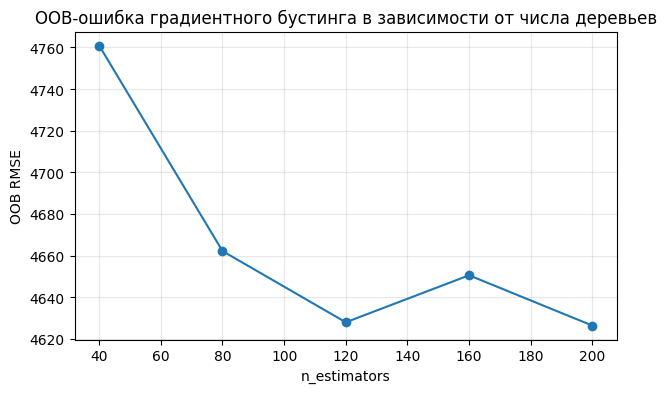

,n_estimators,OOB RMSE
0,40,4760.892748
1,80,4662.194413
2,120,4627.964061
3,160,4650.537397
4,200,4626.380678


In [16]:
oob_curve_rows = []
for n_estimators in [40, 80, 120, 160, 200]:
    curve_params = gb_oob_best_params.copy()
    curve_params['n_estimators'] = n_estimators
    model = GradientBoostingRegressor(loss = 'squared_error',
                                      random_state = 123,
                                      **curve_params)
    model.fit(features_train_raw, target_train)
    oob_curve_rows.append({
        'n_estimators': n_estimators,
        'OOB RMSE': np.sqrt(model.oob_score_)
    })

oob_curve = pd.DataFrame(oob_curve_rows)

plt.figure(figsize = (7, 4))
plt.plot(oob_curve['n_estimators'], oob_curve['OOB RMSE'], marker = 'o')
plt.xlabel('n_estimators')
plt.ylabel('OOB RMSE')
plt.title('OOB-ошибка градиентного бустинга в зависимости от числа деревьев')
plt.grid(alpha = 0.3)
plt.show()

oob_curve

OOB-подбор выбрал конфигурацию `n_estimators=120`, `learning_rate=0.1`, `max_depth=3`, `subsample=0.6`; соответствующая `OOB RMSE` равна `4627.964`. CV-подбор на той же сетке выбрал почти такую же модель, но с `subsample=0.8`; его `CV RMSE` равен `4725.101`.

На тестовой выборке CV-вариант оказался немного лучше по `RMSE`: `4709.166` против `4710.766` у OOB-варианта. По `MAPE` немного лучше OOB-вариант: `94.355` против `94.647`, но из-за очень малых значений `monthly_spending` эта метрика менее устойчива.

Содержательно вывод такой: OOB и CV приводят к очень похожим моделям, различается только доля подвыборки `subsample`. Существенных признаков сильного переобучения у OOB-модели нет: ее тестовое качество близко к CV-варианту и к лучшему градиентному бустингу из основного блока. В качестве основного критерия здесь разумно оставить `RMSE`, поэтому на тесте предпочтительнее CV-подбор, хотя различие с OOB-подбором очень небольшое.

## Задание 4.4, повышенная сложность

**Текст задания.** Включите в анализ дополнительный метод регрессии, не рассматривавшийся в курсе и не представленный в библиотеке `scikit-learn`. Опишите данный метод: принцип работы, преимущества и недостатки. Осуществите тюнинг гиперпараметров и сопоставьте его точность на тестовой выборке с точностью лучшего из обученных ранее методов.

**Выполнение.** Ниже в качестве внешнего метода используется `CatBoostRegressor` из библиотеки `catboost`, выполняется компактный тюнинг гиперпараметров и сравнение с лучшей моделью основного блока. Этот пункт похож на семинарский пример с внешним бустингом: используется библиотека вне стандартного набора `sklearn`, но логика оценки качества остается той же.

В качестве дополнительного метода используем `CatBoostRegressor` из внешней библиотеки `catboost`. CatBoost - это градиентный бустинг над деревьями решений. Как и обычный бустинг, он строит модель в виде суммы базовых деревьев:

$$\hat f_M(x) = \sum_{m=0}^{M}\gamma_m h_m(x).$$

Основные плюсы CatBoost: хорошая работа с табличными данными, способность улавливать нелинейности и взаимодействия признаков, встроенная регуляризация и устойчивость при аккуратном тюнинге. Основные минусы: меньшая интерпретируемость по сравнению с МНК, риск переобучения при слишком сложной настройке, внешняя зависимость и необходимость подбора гиперпараметров.

Для тюнинга используем validation-подход: обучающую выборку из основного блока дополнительно делим на внутренние train и validation части. Это быстрее, чем полная кросс-валидация, и поэтому хорошо подходит для дополнительного внешнего метода.

Схема такая:

$$train \rightarrow train_{inner} \cup validation,$$

где validation используется только для выбора гиперпараметров CatBoost. Тестовая выборка не используется при подборе параметров и остается для финальной оценки качества.

In [17]:
from catboost import CatBoostRegressor

cat_features_train, cat_features_valid, cat_target_train, cat_target_valid = train_test_split(
    features_train_raw, target_train, test_size = 0.2, random_state = 321
)

catboost_param_grid = {
    'iterations': [120, 200],
    'depth': [3, 4],
    'learning_rate': [0.05, 0.1],
    'l2_leaf_reg': [3, 10]
}

catboost_param_list = [
    dict(zip(catboost_param_grid.keys(), values))
    for values in product(*catboost_param_grid.values())
]

pd.Series(catboost_param_grid, name = 'значения')

iterations        [120, 200]
depth                 [3, 4]
learning_rate    [0.05, 0.1]
l2_leaf_reg          [3, 10]
Name: значения, dtype: object

Перебираем небольшую сетку параметров. Для каждой конфигурации обучаем CatBoost на внутренней train-части и считаем `RMSE` и `MAPE` на validation-части. Лучшей выбираем конфигурацию с минимальным validation `RMSE`:

$$\hat\lambda_{CatBoost} = \arg\min_{\lambda \in \Lambda} RMSE_{valid}(\lambda).$$

В сетку входят `iterations`, `depth`, `learning_rate` и `l2_leaf_reg`. Последний параметр отвечает за L2-регуляризацию листьев дерева и помогает ограничивать переобучение.

In [18]:
catboost_rows = []
catboost_models = {}

for params in catboost_param_list:
    model = CatBoostRegressor(loss_function = 'RMSE',
                              random_seed = 123,
                              verbose = False,
                              allow_writing_files = False,
                              **params)
    model.fit(cat_features_train, cat_target_train)
    valid_pred = model.predict(cat_features_valid)
    params_text = (f"iterations={params['iterations']}, depth={params['depth']}, "
                   f"learning_rate={params['learning_rate']}, l2_leaf_reg={params['l2_leaf_reg']}")
    catboost_models[params_text] = model
    catboost_rows.append({
        'best_params': params_text,
        'validation RMSE': rmse(cat_target_valid, valid_pred),
        'validation MAPE': mape(cat_target_valid, valid_pred),
        'params_dict': params
    })

catboost_tuning_results = pd.DataFrame(catboost_rows).sort_values('validation RMSE').reset_index(drop = True)
catboost_best_params = catboost_tuning_results.loc[0, 'params_dict']
catboost_best_params_text = catboost_tuning_results.loc[0, 'best_params']
catboost_best_validation_rmse = catboost_tuning_results.loc[0, 'validation RMSE']
catboost_best_validation_mape = catboost_tuning_results.loc[0, 'validation MAPE']

catboost_tuning_results.drop(columns = 'params_dict').head(8).round(3)

,best_params,validation RMSE,validation MAPE
0,"iterations=200, depth=3, learning_rate=0.1, l2_leaf_reg=3",4701.592,87.809
1,"iterations=200, depth=3, learning_rate=0.1, l2_leaf_reg=10",4703.712,87.663
2,"iterations=200, depth=4, learning_rate=0.1, l2_leaf_reg=3",4703.936,88.543
3,"iterations=200, depth=4, learning_rate=0.1, l2_leaf_reg=10",4704.318,88.170
4,"iterations=200, depth=4, learning_rate=0.05, l2_leaf_reg=3",4707.943,88.848
5,"iterations=120, depth=4, learning_rate=0.1, l2_leaf_reg=10",4708.272,88.294
6,"iterations=120, depth=4, learning_rate=0.1, l2_leaf_reg=3",4708.760,88.430
7,"iterations=200, depth=4, learning_rate=0.05, l2_leaf_reg=10",4708.920,88.958


После выбора гиперпараметров обучаем финальный `CatBoostRegressor` уже на всей обучающей выборке из основного блока. Это стандартный шаг после тюнинга: validation использовалась только для выбора параметров, а финальная модель получает максимум доступных обучающих данных. Затем качество оценивается на test по тем же метрикам `RMSE` и `MAPE`, что и у всех остальных моделей.

In [19]:
catboost_best_model = CatBoostRegressor(loss_function = 'RMSE',
                                           random_seed = 123,
                                           verbose = False,
                                           allow_writing_files = False,
                                           **catboost_best_params)
catboost_best_model.fit(features_train_raw, target_train)
catboost_pred_test = catboost_best_model.predict(features_test_raw)

catboost_test_rmse = rmse(target_test, catboost_pred_test)
catboost_test_mape = mape(target_test, catboost_pred_test)

pd.Series({
    'best_params': catboost_best_params_text,
    'validation RMSE': catboost_best_validation_rmse,
    'validation MAPE': catboost_best_validation_mape,
    'test RMSE': catboost_test_rmse,
    'test MAPE': catboost_test_mape
})

best_params        iterations=200, depth=3, learning_rate=0.1, l2_leaf_reg=3
validation RMSE                                                  4701.591705
validation MAPE                                                    87.808643
test RMSE                                                        4698.182096
test MAPE                                                          94.002601
dtype: object

Сравниваем CatBoost с лучшей моделью из основного блока регрессии. Для честного сопоставления используются одна и та же тестовая выборка и одни и те же функции `RMSE` и `MAPE`. Дополнительно считаем разрыв относительно лучшей основной модели:

$$Gap_{RMSE}^{CatBoost} = RMSE_{CatBoost,test} - RMSE_{best,test}.$$

Отрицательное значение разрыва означает, что CatBoost улучшил качество относительно лучшей модели основного блока.

In [20]:
catboost_vs_main = pd.DataFrame({
    'method': [best_regressor_name, 'CatBoostRegressor'],
    'source': ['основной блок регрессии', 'дополнительный внешний метод'],
    'best_params': [regression_all_summary.loc[best_regressor_name, 'подобранные гиперпараметры'],
                    catboost_best_params_text],
    'validation/CV RMSE': [regression_all_summary.loc[best_regressor_name, 'RMSE-CV после тюнинга'],
                           catboost_best_validation_rmse],
    'test RMSE': [regression_final_all.loc[best_regressor_name, 'RMSE test'],
                  catboost_test_rmse],
    'test MAPE': [regression_final_all.loc[best_regressor_name, 'MAPE test'],
                  catboost_test_mape]
})

catboost_vs_main['RMSE gap vs main best'] = catboost_vs_main['test RMSE'] - regression_final_all.loc[best_regressor_name, 'RMSE test']
catboost_vs_main['MAPE gap vs main best'] = catboost_vs_main['test MAPE'] - regression_final_all.loc[best_regressor_name, 'MAPE test']

catboost_vs_main.round(3)

,method,source,best_params,validation/CV RMSE,test RMSE,test MAPE,RMSE gap vs main best,MAPE gap vs main best
0,Градиентный бустинг,основной блок регрессии,"{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 120}",4728.383,4710.356,94.661,0.000,0.000
1,CatBoostRegressor,дополнительный внешний метод,"iterations=200, depth=3, learning_rate=0.1, l2_leaf_reg=3",4701.592,4698.182,94.003,-12.174,-0.659


CatBoost использует внешний метод, не входящий в `sklearn`, и поэтому закрывает дополнительный пункт повышенной сложности. Лучшие гиперпараметры по validation `RMSE`: `iterations=200`, `depth=3`, `learning_rate=0.1`, `l2_leaf_reg=3`.

На тестовой выборке CatBoost дал `RMSE = 4698.182` и `MAPE = 94.003`. Это лучше лучшей модели из основного блока, градиентного бустинга из `sklearn`, у которого `RMSE = 4710.356` и `MAPE = 94.661`. Улучшение по `RMSE` составляет примерно `12.174` единицы целевой переменной, а по `MAPE` примерно `0.659`.

Следовательно, в этой задаче CatBoost дает небольшое, но заметное улучшение качества. Это содержательно объяснимо: CatBoost, как более продвинутый вариант бустинга над деревьями, лучше подстраивается под нелинейности и взаимодействия в табличных данных. При этом выигрыш не огромный, поэтому с практической точки зрения нужно учитывать и стоимость внешней зависимости. Основной вывод лучше делать по `RMSE`, потому что `MAPE` остается менее устойчивой метрикой из-за очень малых значений `monthly_spending`.